In [1]:
import os
import numpy as np
from scipy.sparse import issparse
from scipy.signal import hilbert
from scipy.spatial import cKDTree, KDTree
import matplotlib.pyplot as plt
import nibabel as nib

from lameg.invert import coregister, invert_ebb, load_source_time_series, _load_inverse_components, _pad_or_trim_sensor_to_temp_projector, _restore_time_length
from lameg.laminar import model_comparison, roi_power_comparison
from lameg.surf import LayerSurfaceSet
from lameg.util import load_meg_sensor_data, get_fiducial_coords, ttest_rel_corrected
from lameg.viz import show_surface, verify_coregistration, color_map

import spm_standalone

In [2]:
spm = spm_standalone.initialize()

In [1]:
%env SUBJECTS_DIR=/home/bonaiuto/laminar_cued_action_opm/OPM-LMN.260209/anat/fs/

env: SUBJECTS_DIR=/home/bonaiuto/laminar_cued_action_opm/OPM-LMN.260209/anat/fs/


In [4]:
# Subject information
subj_id = 'S01_CZZ'

# Fiducial coil coordinates
fid_coords = get_fiducial_coords(
    f'{subj_id}-R1',
    '/home/bonaiuto/laminar_cued_action_opm/OPM-LMN.260209/squid/fiducial_coords.tsv',
    subject_column='subject_id',
    nas_column='NAS', lpa_column='LPA', rpa_column='RPA'
)

# Data file
data_file = os.path.join('/home/bonaiuto/laminar_cued_action_opm/OPM-LMN.260209/squid/proc/', subj_id, 'spm_all-epo.mat')

In [5]:
def load_layer_power(data_fname, woi, baseline_woi, surf_set, roi_idx, chunk_size=100):
    verts_per_surf = surf_set.get_vertices_per_layer()
    n_layers = surf_set.n_layers

    pial_vertices = np.arange(verts_per_surf)

    # Load time indices
    ts_v, time, _ = load_source_time_series(
        data_fname,
        vertices=pial_vertices[:1]
    )
    n_trials = ts_v.shape[2]
    base_t_idx = np.where((time >= baseline_woi[0]) & (time < baseline_woi[1]))[0]
    exp_t_idx = np.where((time >= woi[0]) & (time < woi[1]))[0]

    def load_and_compute_power(vertices, n_trials, chunk_size):
        vertices = np.asarray(vertices, dtype=int)
        base_incremental_power = np.zeros((len(vertices), n_trials))
        exp_incremental_power = np.zeros((len(vertices), n_trials))

        if len(vertices) == 0:
            return base_incremental_power, exp_incremental_power

        chunk_size = min(chunk_size, len(vertices))

        for start in range(0, len(vertices), chunk_size):
            end = min(start + chunk_size, len(vertices))
            vertex_slice = vertices[start:end]

            ts_chunk, _, _ = load_source_time_series(
                data_fname,
                vertices=vertex_slice
            )
            envelope = np.abs(hilbert(ts_chunk, axis=1))

            base_power_chunk = np.squeeze(np.mean(envelope[:, base_t_idx, :], axis=1))
            exp_power_chunk = np.squeeze(np.mean(envelope[:, exp_t_idx, :], axis=1))

            if base_power_chunk.ndim == 1:
                base_power_chunk = base_power_chunk[np.newaxis, :]
            if exp_power_chunk.ndim == 1:
                exp_power_chunk = exp_power_chunk[np.newaxis, :]

            base_incremental_power[start:end, :] = base_power_chunk
            exp_incremental_power[start:end, :] = exp_power_chunk

            del ts_chunk, envelope

        return base_incremental_power, exp_incremental_power

    roi_idx = np.asarray(roi_idx, dtype=int)
    pial_roi_idx = roi_idx
    
    pial_base_power, pial_exp_power = load_and_compute_power(
        pial_roi_idx,
        n_trials,
        min(len(pial_roi_idx), chunk_size)
    )
    laminar_t_statistic, deg_of_freedom, laminar_p_value = ttest_rel_corrected(
        pial_exp_power - pial_base_power,
        axis=-1
    )
    return laminar_t_statistic


def load_roi_power_ts(data_fname, baseline_woi, surf_set, roi_idx, chunk_size=100):
    verts_per_surf = surf_set.get_vertices_per_layer()
    n_layers = surf_set.n_layers
    
    # Load time indices
    ts_v, time, _ = load_source_time_series(
        data_fname,
        vertices=[0]
    )
    n_trials = ts_v.shape[2]
    base_t_idx = np.where((time >= baseline_woi[0]) & (time < baseline_woi[1]))[0]
    
    def load_and_compute_power(vertices, n_trials, chunk_size):
        vertices = np.asarray(vertices, dtype=int)
        exp_incremental_ts = np.zeros((len(vertices), len(time), n_trials))

        if len(vertices) == 0:
            return exp_incremental_ts

        chunk_size = min(chunk_size, len(vertices))

        for start in range(0, len(vertices), chunk_size):
            end = min(start + chunk_size, len(vertices))
            vertex_slice = vertices[start:end]

            ts_chunk, _, _ = load_source_time_series(
                data_fname,
                vertices=vertex_slice
            )
            envelope = np.abs(hilbert(ts_chunk, axis=1))

            base_power_chunk = np.mean(envelope[:, base_t_idx, :], axis=1)
            
            if base_power_chunk.ndim == 1:
                base_power_chunk = base_power_chunk[np.newaxis, :]
            
            exp_incremental_ts[start:end, :, :] = envelope - base_power_chunk[:, np.newaxis, :]

            del ts_chunk, envelope

        return exp_incremental_ts

    roi_idx = np.asarray(roi_idx, dtype=int)
    pial_roi_idx = roi_idx
    white_roi_idx = verts_per_surf+roi_idx
    
    pial_exp_power_ts = load_and_compute_power(
        pial_roi_idx,
        n_trials,
        min(len(pial_roi_idx), chunk_size)
    )
    white_exp_power_ts = load_and_compute_power(
        white_roi_idx,
        n_trials,
        min(len(white_roi_idx), chunk_size)
    )
    
    return pial_exp_power_ts, white_exp_power_ts, time

In [6]:
surf_set_bilam = LayerSurfaceSet(subj_id, 2)

In [7]:
# Coregister data to multilayer mesh
coregister(
    fid_coords, 
    data_file,
    surf_set_bilam,
    fid_labels=['Nasion','LPA','RPA'],
    spm_instance=spm
)

SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM - https://www.fil.ion.ucl.ac.uk/spm/

Initialising batch system... done.


------------------------------------------------------------------------
06-Apr-2026 08:54:55 - Running job #1
------------------------------------------------------------------------
06-Apr-2026 08:54:55 - Running 'Head model specification'

SPM: spm_eeg_inv_mesh_ui                           08:54:57 - 06/04/2026
multilayer.2.ds.link_vector.fixed
creating layout from cfg.grad
creating layout for neuromag306 system

SPM: spm_eeg_inv_forward                           08:57:45 - 06/04/2026
Completed                               :          08:57:46 - 06/04/2026
computing surface normals
06-Apr-2026 08:57:48 - Done    'Head mode

In [8]:
cam_view=[-0.236, 0.207, 0.082,
          0.001, 0.026, 0.066,
          0.097, 0.135, 0.986]
plot = verify_coregistration(data_file, surf_set_bilam, fid_coords=fid_coords, camera_view=cam_view)

RMSE of rigid transformation between forward model mesh and surf_set mesh is 3.3069374087056515e-17.
If this is high, coregistration may not have been done using /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S01_CZZ/surf/laminar/multilayer.2.ds.link_vector.fixed.gii.
Either run coregistration with this mesh, or change parameters to match the mesh coregistration was done with.


Output()

In [9]:
v1_roi_idx = surf_set_bilam.get_roi_idx(['V1_exvivo'], atlas='BA_exvivo')
print(v1_roi_idx.shape)

(1117,)


In [14]:
cam_view=[50.00, -207.71, -118.80,
          60.23, 18.16, -47.44,
          0.00, -0.34, 0.94]

In [11]:
alpha_foi=[7,13]
alpha_base_woi=[-1000,0]
alpha_exp_woi=[0, 1000]

In [12]:
# Run inversion
[_,_] = invert_ebb(
    data_file, 
    surf_set_bilam,
    foi=alpha_foi,
    patch_size=5, 
    n_temp_modes=4,
    spm_instance=spm
)

Smoothing /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S01_CZZ/surf/laminar/multilayer.2.ds.link_vector.fixed.gii

smoothmeshname =

    '/home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S01_CZZ/surf/laminar/FWHM5.00_multilayer.2.ds.link_vector.fixed.mat'


Found smoothfile /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S01_CZZ/surf/laminar/FWHM5.00_multilayer.2.ds.link_vector.fixed.mat, not recomputing
Removed 0 bad channels

Taking random selections of 0.00 percent of channels
Using 0 spatial modes

        SPM: spm_eeg_lgainmat                      08:57:50 - 06/04/2026
        ----------------------------------------------------------------
computing surface normals
Starting parallel pool (parpool) using the 'local' profile ...
Preserving jobs with IDs: 5 because they contain crash dump files.
You can use 'delete(myCluster.Jobs)' to remove all jobs created with profile local. To create 'myCluster' use 'myCluster = parcluster('local')'.
Connected to the parallel pool (numbe

t(890)=-46.20864199121231, p=1.104316492603588e-238


Output()

32791 vertices


/home/bonaiuto/miniconda3/envs/lameg_dev/lib/python3.7/site-packages/lameg/util.py:623: RuntimeWarning: invalid value encountered in double_scalars
  tval = (xmean - 0) / ser


Text(0, 0.5, 'Density')

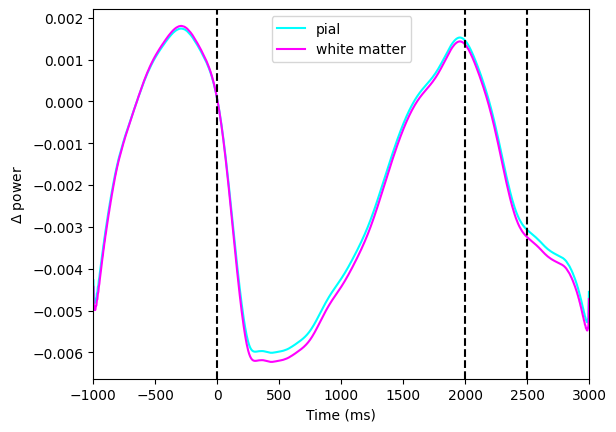

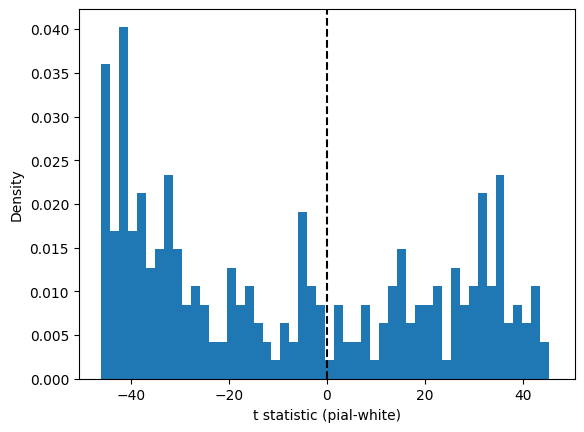

In [15]:
laminar_t_statistic, laminar_p_value, df, alpha_roi_idx = roi_power_comparison(
    data_file,
    alpha_exp_woi,
    alpha_base_woi,
    80,
    surf_set_bilam,
    roi_idx=v1_roi_idx,
    roi_mode="restrict_threshold",
    chunk_size=100
)
print(f"t({df})={laminar_t_statistic}, p={laminar_p_value}")

alpha_pial_power = load_layer_power(
    data_file, 
    alpha_exp_woi,
    alpha_base_woi, 
    surf_set_bilam,
    alpha_roi_idx,
    chunk_size=100
)
alpha_layer_power=np.zeros(surf_set_bilam.get_vertices_per_layer())
alpha_layer_power[alpha_roi_idx]=alpha_pial_power
v_colors, c_map = color_map(
    alpha_layer_power, 
    "RdYlBu_r", 
    -np.max(np.abs(alpha_layer_power)), 
    np.max(np.abs(alpha_layer_power))
)
v_colors_thresh = np.zeros((v_colors.shape[0], 4))
v_colors_thresh[:, :3] = v_colors
v_colors_thresh[np.abs(alpha_layer_power)>0, -1] = 255
plot = show_surface(
    surf_set_bilam,
    layer_name="inflated",
    stage="ds",
    vertex_colors=v_colors_thresh,
    info=True,
    camera_view=cam_view
)

alpha_pial_bc_power, alpha_white_bc_power, time = load_roi_power_ts(
    data_file, 
    alpha_base_woi, 
    surf_set_bilam, 
    alpha_roi_idx, 
    chunk_size=100
)
col_r = plt.cm.cool(np.linspace(0, 1, num=2))
roi_pial_bc_power = np.mean(alpha_pial_bc_power, axis=0)
roi_white_bc_power = np.mean(alpha_white_bc_power, axis=0)
m_pial_bc_power = np.mean(roi_pial_bc_power, axis=-1)
m_white_bc_power = np.mean(roi_white_bc_power, axis=-1)
plt.figure()
plt.plot(time, m_pial_bc_power, label="pial", color=col_r[0, :])
plt.plot(time, m_white_bc_power, label="white matter", color=col_r[1, :])
plt.axvline(0, color="k", linestyle="--")
plt.axvline(2000, color="k", linestyle="--")
plt.axvline(2500, color="k", linestyle="--")
plt.xlim([-1000, 3000])
plt.xlabel("Time (ms)")
plt.ylabel("$\\Delta$ power")
plt.legend()

exp_t_idx = (time >= alpha_exp_woi[0]) & (time <= alpha_exp_woi[1])
alpha_t_stats=[]
for x in range(len(alpha_roi_idx)):
    roi_pial_bc = alpha_pial_bc_power[x, :, :]
    roi_pial_bc = np.mean(roi_pial_bc[exp_t_idx, :], axis=0)

    roi_white_bc = alpha_white_bc_power[x, :, :]
    roi_white_bc = np.mean(roi_white_bc[exp_t_idx, :], axis=0)

    v_t_stat, v_dof, v_p = ttest_rel_corrected(
        np.abs(roi_pial_bc) - np.abs(roi_white_bc),
        axis=-1,
    )
    alpha_t_stats.append(v_t_stat)
plt.figure()
plt.hist(alpha_t_stats, 50, density=True)
plt.axvline(0, color="k", linestyle="--")
xl = plt.xlim()
xlim = [-np.max(np.abs(xl)), np.max(np.abs(xl))]
plt.xlim(xlim)
plt.xlabel("t statistic (pial-white)")
plt.ylabel("Density")

In [16]:
gamma_foi=[60,90]
gamma_base_woi=[-1000,0]
gamma_exp_woi=[0, 500]

In [17]:
# Run inversion
[_,_] = invert_ebb(
    data_file, 
    surf_set_bilam,
    foi=gamma_foi,
    patch_size=5, 
    n_temp_modes=4,
    spm_instance=spm
)

Smoothing /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S01_CZZ/surf/laminar/multilayer.2.ds.link_vector.fixed.gii
IdleTimeout has been reached.
Parallel pool using the 'local' profile is shutting down.

smoothmeshname =

    '/home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S01_CZZ/surf/laminar/FWHM5.00_multilayer.2.ds.link_vector.fixed.mat'


Found smoothfile /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S01_CZZ/surf/laminar/FWHM5.00_multilayer.2.ds.link_vector.fixed.mat, not recomputing
Removed 0 bad channels

Taking random selections of 0.00 percent of channels
Using 0 spatial modes

Preparing modes file  block 1 of 1 for 102 training and 0 test chans

 saving spatial mode file /home/bonaiuto/laminar_opm/OPM-LMN.260209/squid/proc/S01_CZZ/spm_all-epo_testmodes.mat
SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )__

t(890)=23.635772049218602, p=3.0416449059458458e-96


Output()

32791 vertices


Text(0, 0.5, 'Density')

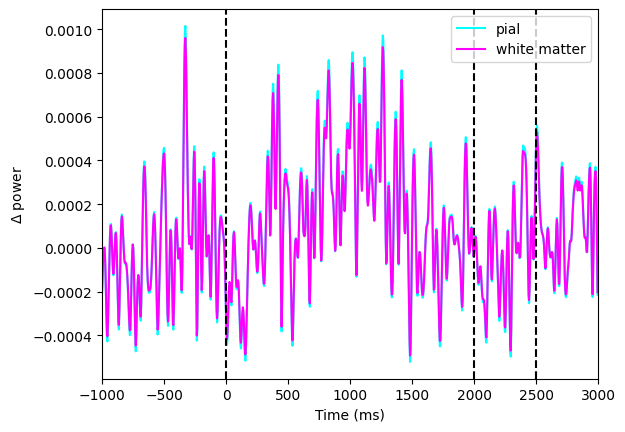

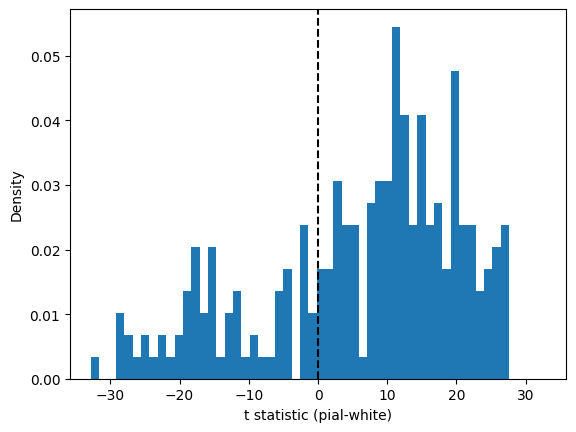

In [18]:
laminar_t_statistic, laminar_p_value, df, gamma_roi_idx = roi_power_comparison(
    data_file,
    gamma_exp_woi,
    gamma_base_woi,
    80,
    surf_set_bilam,
    roi_idx=v1_roi_idx,
    roi_mode="restrict_threshold",
    chunk_size=100
)
print(f"t({df})={laminar_t_statistic}, p={laminar_p_value}")

gamma_pial_power = load_layer_power(
    data_file, 
    gamma_exp_woi,
    gamma_base_woi, 
    surf_set_bilam,
    gamma_roi_idx,
    chunk_size=100
)
gamma_layer_power=np.zeros(surf_set_bilam.get_vertices_per_layer())
gamma_layer_power[gamma_roi_idx]=gamma_pial_power
v_colors, c_map = color_map(
    gamma_layer_power, 
    "RdYlBu_r", 
    -np.max(np.abs(gamma_layer_power)), 
    np.max(np.abs(gamma_layer_power))
)
v_colors_thresh = np.zeros((v_colors.shape[0], 4))
v_colors_thresh[:, :3] = v_colors
v_colors_thresh[np.abs(gamma_layer_power)>0, -1] = 255
plot = show_surface(
    surf_set_bilam,
    layer_name="inflated",
    stage="ds",
    vertex_colors=v_colors_thresh,
    info=True,
    camera_view=cam_view
)

gamma_pial_bc_power, gamma_white_bc_power, time = load_roi_power_ts(
    data_file, 
    gamma_base_woi, 
    surf_set_bilam, 
    gamma_roi_idx, 
    chunk_size=100
)
col_r = plt.cm.cool(np.linspace(0, 1, num=2))
roi_pial_bc_power = np.mean(gamma_pial_bc_power, axis=0)
roi_white_bc_power = np.mean(gamma_white_bc_power, axis=0)
m_pial_bc_power = np.mean(roi_pial_bc_power, axis=-1)
m_white_bc_power = np.mean(roi_white_bc_power, axis=-1)
plt.figure()
plt.plot(time, m_pial_bc_power, label="pial", color=col_r[0, :])
plt.plot(time, m_white_bc_power, label="white matter", color=col_r[1, :])
plt.axvline(0, color="k", linestyle="--")
plt.axvline(2000, color="k", linestyle="--")
plt.axvline(2500, color="k", linestyle="--")
plt.xlim([-1000, 3000])
plt.xlabel("Time (ms)")
plt.ylabel("$\\Delta$ power")
plt.legend()

exp_t_idx = (time >= gamma_exp_woi[0]) & (time <= gamma_exp_woi[1])
gamma_t_stats=[]
for x in range(len(gamma_roi_idx)):
    roi_pial_bc = gamma_pial_bc_power[x, :, :]
    roi_pial_bc = np.mean(roi_pial_bc[exp_t_idx, :], axis=0)

    roi_white_bc = gamma_white_bc_power[x, :, :]
    roi_white_bc = np.mean(roi_white_bc[exp_t_idx, :], axis=0)

    v_t_stat, v_dof, v_p = ttest_rel_corrected(
        np.abs(roi_pial_bc) - np.abs(roi_white_bc),
        axis=-1,
    )
    gamma_t_stats.append(v_t_stat)
plt.figure()
plt.hist(gamma_t_stats, 50, density=True)
plt.axvline(0, color="k", linestyle="--")
xl = plt.xlim()
xlim = [-np.max(np.abs(xl)), np.max(np.abs(xl))]
plt.xlim(xlim)
plt.xlabel("t statistic (pial-white)")
plt.ylabel("Density")

In [16]:
# spm.terminate()